In [46]:
# Librerias para vision artificial

import cv2
import matplotlib.pyplot as plt
import numpy as np


Deteccion de la placa del auto

In [47]:
cv2.data.haarcascades

'c:\\Users\\Darck\\anaconda3\\envs\\diplomado-redes\\Lib\\site-packages\\cv2\\data\\'

In [48]:
!dir C:\Users\Darck\anaconda3\envs\diplomado-redes\Lib\site-packages\cv2\data

 El volumen de la unidad C es Loli Kingdom
 El n�mero de serie del volumen es: F2E0-74EA

 Directorio de C:\Users\Darck\anaconda3\envs\diplomado-redes\Lib\site-packages\cv2\data

15/04/2026  07:43 p. m.    <DIR>          .
15/04/2026  07:43 p. m.    <DIR>          ..
15/04/2026  07:43 p. m.           341,406 haarcascade_eye.xml
15/04/2026  07:43 p. m.           601,661 haarcascade_eye_tree_eyeglasses.xml
15/04/2026  07:43 p. m.           411,388 haarcascade_frontalcatface.xml
15/04/2026  07:43 p. m.           382,918 haarcascade_frontalcatface_extended.xml
15/04/2026  07:43 p. m.           676,709 haarcascade_frontalface_alt.xml
15/04/2026  07:43 p. m.           540,616 haarcascade_frontalface_alt2.xml
15/04/2026  07:43 p. m.         2,689,040 haarcascade_frontalface_alt_tree.xml
15/04/2026  07:43 p. m.           930,127 haarcascade_frontalface_default.xml
15/04/2026  07:43 p. m.           476,827 haarcascade_fullbody.xml
15/04/2026  07:43 p. m.           195,369 haarcascade_lefteye_2s

In [49]:
# Cargando el modelo preentrenado

plate_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_russian_plate_number.xml')

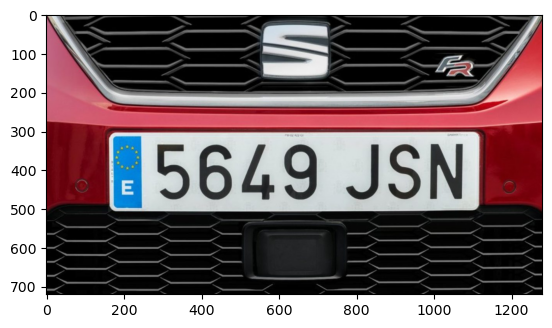

In [50]:
# Lectura de la imagen
img = cv2.imread('F:\Proyectos\Diplomado-RNA\Modulo-3\Material\Plates\placa2.jpg')

# Conversion de formato
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.imshow(img, cmap='Accent')
plt.show()


In [51]:
# Deteccion de placas

placas = plate_cascade.detectMultiScale(img, 1.3 , 3) # al momento de usar 1.3 nuestro performance mejora
print(placas)

[[ 128  216 1075  358]]


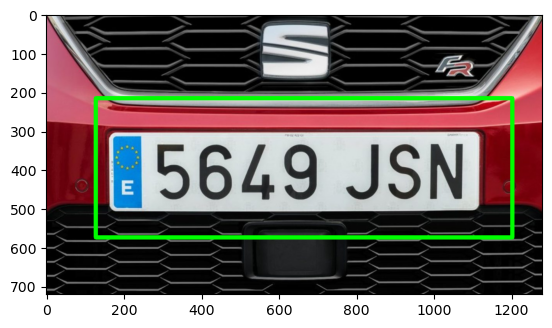

In [52]:
# Dibujo del cuadro delimitador de la placa

img_copy = np.copy(img)
for (x,y,w,h) in placas:
    cv2.rectangle(img_copy, (x,y), (x+w,y+h), (0,255,0), 10)
    
    
plt.imshow(img_copy, cmap = 'Accent')
plt.show(  )


Extraccion del texto

In [ ]:
# Asi instalamos librerias que no estan por default en colaboratory
pip install pytesseract
sudo apt install tesseract-ocr
sudo apt install libtesseract-dev

# Nota, investigar como instalar tesseract*ocr y libtesseract-dev en windows 11 y tambien dejar la nota para instalarlo en ubuntu de la escuela

In [53]:
# libreria OCR

import pytesseract      #modelo pre-entrenado de DL Usa RNC (multicapa)

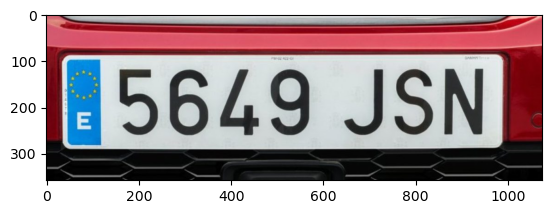

In [54]:
placaRGB = img[y:y+h,x:x+w, :]      #Ayudamos a la imagen a recortarla para quitarle/disminuir un poco de ruido

plt.imshow(placaRGB, cmap= 'Accent')    
plt.show()


In [ ]:
#pip install Pillow==9.0.0 

Prueba 1, Imagen a Color

In [55]:
textoRGB = pytesseract.image_to_string(placaRGB)
print(textoRGB)

TesseractNotFoundError: tesseract is not installed or it's not in your PATH. See README file for more information.

Prueba 2 Imagen a Escala de grises

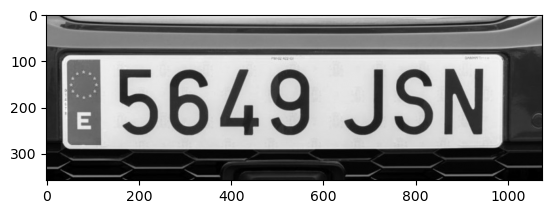

In [56]:
# Convertimos a escala de grises

placaGary = cv2.cvtColor(placaRGB,  cv2.COLOR_RGB2GRAY)

plt.imshow(placaGary, cmap='gray')
plt.show()


In [40]:
textoGray = pytesseract.image_to_string(placaGary)
print(textoGray)

TesseractNotFoundError: tesseract is not installed or it's not in your PATH. See README file for more information.

Prueba 3 Imagen filtrada

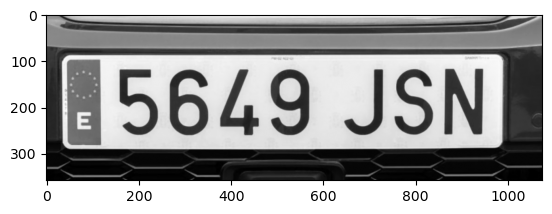

In [41]:
# Filtro de mediana sobre la imagen

placaFiltrada = cv2.medianBlur(placaGary, 3)

plt.imshow(placaFiltrada, cmap='gray')
plt.show()

In [42]:
textoFiltro = pytesseract.image_to_string(placaFiltrada)
print(textoFiltro)

TesseractNotFoundError: tesseract is not installed or it's not in your PATH. See README file for more information.

Prueba 4 Binarizar imagen

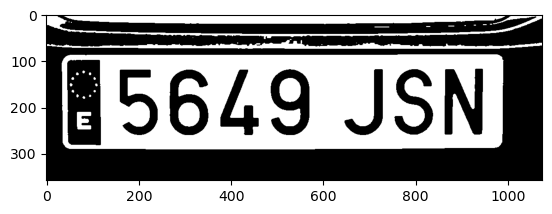

In [ ]:
# Binarizando por medio de un limite

ret, placaBin = cv2.threshold(placaFiltrada, 130 , 1 , cv2.THRESH_BINARY) # modificando el hold entre 120 a 150 para tener una mejor lectura de los numeros

plt.imshow(placaBin, cmap='gray')
plt.show()

In [44]:
textoBin = pytesseract.image_to_string(placaBin)
print(textoBin)

TesseractNotFoundError: tesseract is not installed or it's not in your PATH. See README file for more information.

Podriasmos ayudarle al algoritmo agregando tal vez, un if de que si son placas iguales, osea, que sean de mexico oh de europa oh asi, tenga alguna config espesifica, para ese tipo de placas